In [183]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import seaborn as sns
%matplotlib inline

In [184]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity='all'

In [185]:
import warnings 
warnings.filterwarnings('ignore')

### Read the input file 'Diabetes.csv' using Pandas and check it's column names(1 Marks)

In [186]:
df = pd.read_csv("./diabetes.csv")
col_name_full = list(df.columns)
orig_diabetes_df = df.loc[:,col_name_full]
orig_diabetes_df.sample(n=8, random_state=2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
158,2,88,74,19,53,29.0,0.229,22,0
251,2,129,84,0,0,28.0,0.284,27,0
631,0,102,78,40,90,34.5,0.238,24,0
757,0,123,72,0,0,36.3,0.258,52,1
689,1,144,82,46,180,46.1,0.335,46,1
573,2,98,60,17,120,34.7,0.198,22,0
553,1,88,62,24,44,29.9,0.422,23,0
728,2,175,88,0,0,22.9,0.326,22,0


### Check dimension of dataset

In [187]:
# Eye ball the imported dataset
orig_diabetes_df.shape


(768, 9)

In [188]:
#Below we use *.info() & *.isnull().any() to find out any null value present
orig_diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies                 768 non-null int64
Glucose                     768 non-null int64
BloodPressure               768 non-null int64
SkinThickness               768 non-null int64
Insulin                     768 non-null int64
BMI                         768 non-null float64
DiabetesPedigreeFunction    768 non-null float64
Age                         768 non-null int64
Outcome                     768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [189]:
orig_diabetes_df.isnull().any()

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

### Check distribution of dependent variable, Outcome and plot it (1 Marks)

### Out of 768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes¶

In [190]:
#The response variable "Outcome" is distributed in the following way across 1 & 0s.
orig_diabetes_df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [191]:
#Another way to look at the target column which is 'Outcome' distribution
orig_diabetes_df.groupby(["Outcome"]).count()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,500,500,500,500,500,500,500,500
1,268,268,268,268,268,268,268,268


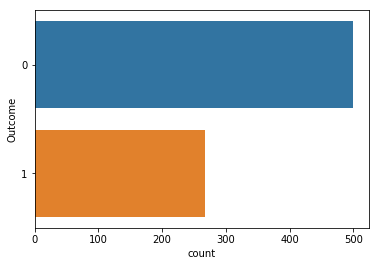

In [192]:
#Yet another way to look at it may be
plot = sns.countplot(y = "Outcome", data = orig_diabetes_df)
plot.set_yticklabels(plot.get_yticklabels());

### Check data distribution using summary statistics and provide your findings(2 Marks)

In [193]:
#We need to have a look into the "descriptive stats" for individual feature distributions
#as follows...followed by a pairplot first and an indivudal histograms later.
orig_diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [194]:
#For ploting the "individual" detailed spread of the histogram, the follwoing function
#is being written...here, default "cut-points" value is 40, & all the "quant" features (which actually are, all of them)
#are selected by using the "describe", without the "all" option, dataframe.Then we loop thru individual feature, and the 
#feature-min to feature-max is divided into the cut-points (default 40) & plotted in turn.
def show_quant_feature_hist_plot(df, cut_pts=40, fig_height=15, fig_len=20):
    #defaul
    descr_trans_df = df.describe()
    for feature in list(descr_trans_df.T.index):
        bins = np.linspace(descr_trans_df[feature]['min'], descr_trans_df[feature]['max'], cut_pts)
        pyplot.subplots(figsize=(fig_len,fig_height))
        #pyplot.hist(df[feature], bins, alpha=0.5, normed=True, label=str(feature)) 
        pyplot.hist(df[feature], bins, alpha=0.5, label=str(feature))
        pyplot.legend(loc='upper right')
        pyplot.show()

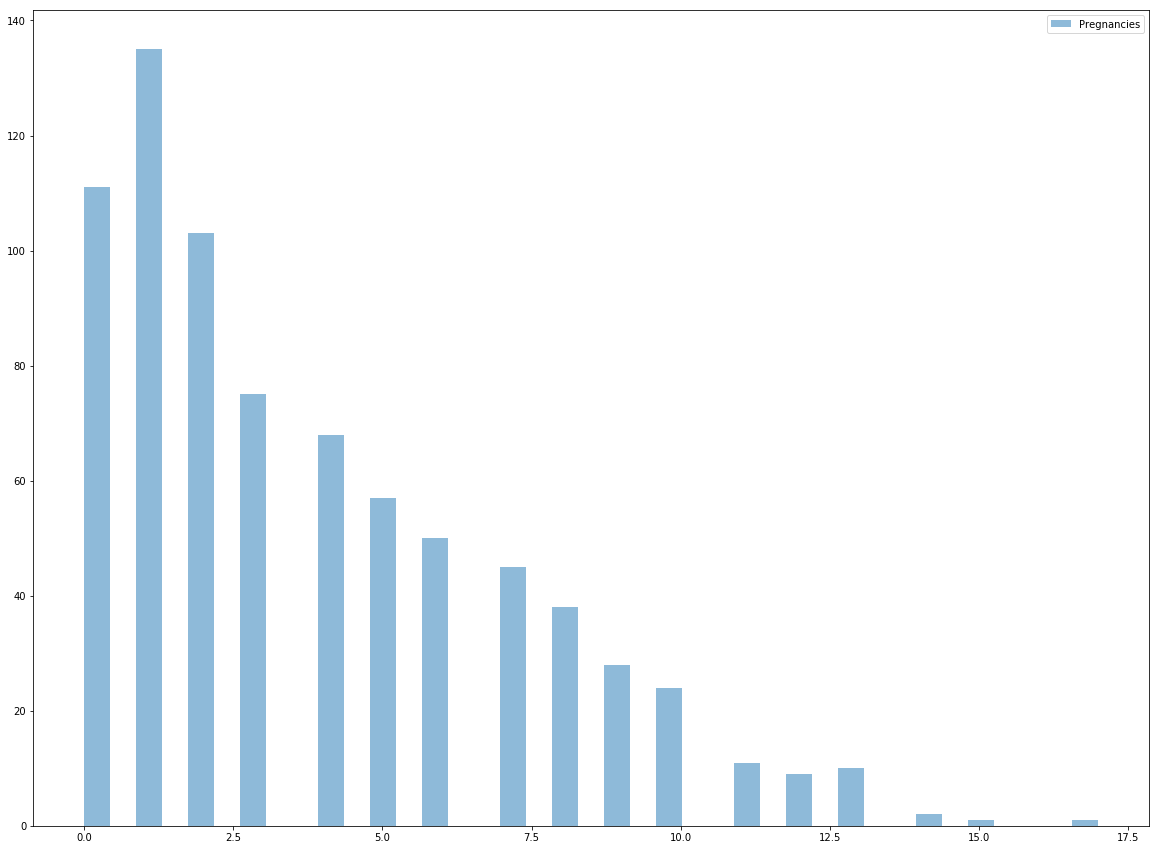

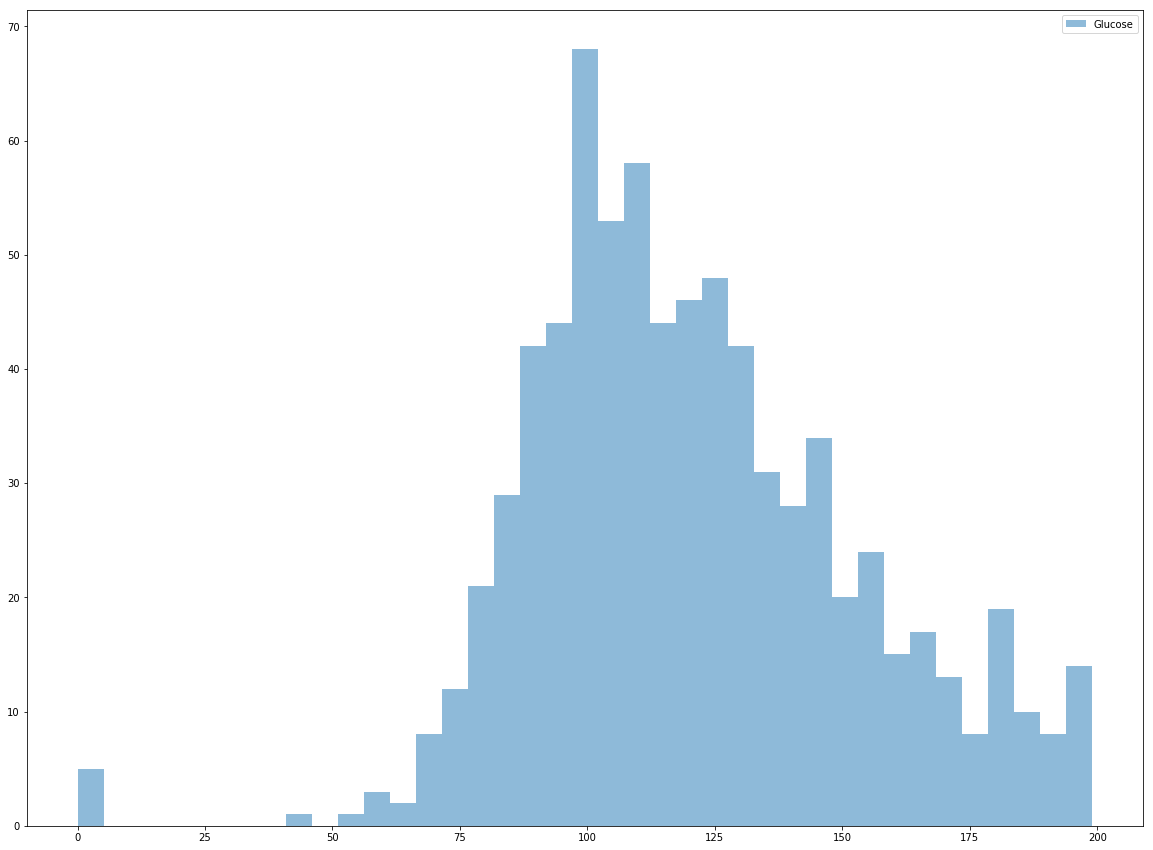

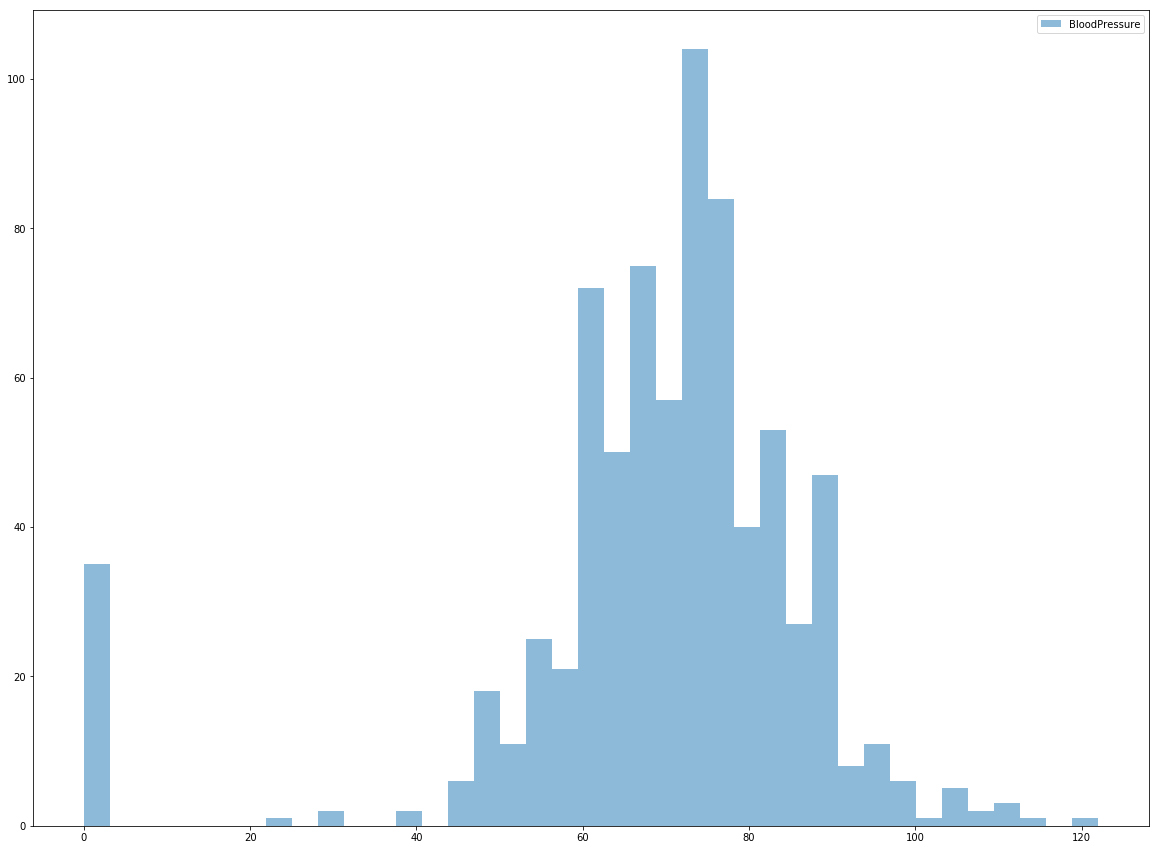

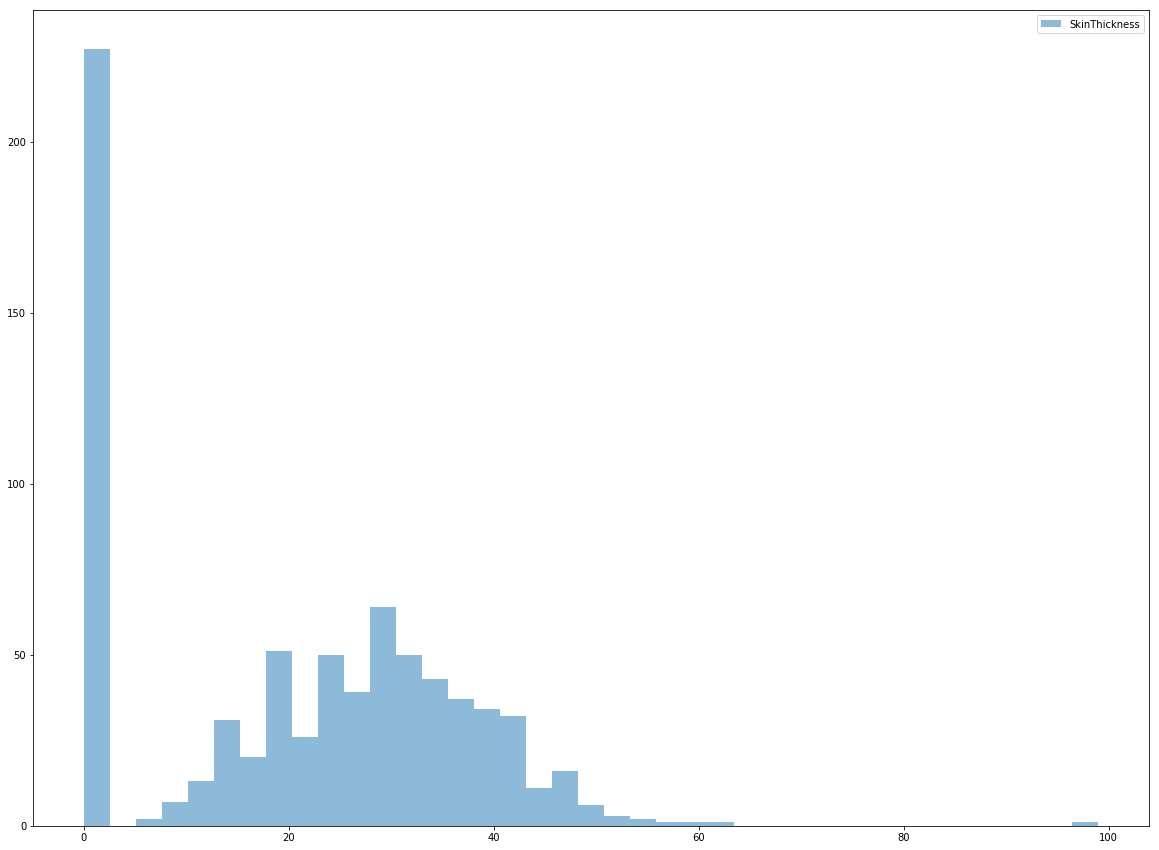

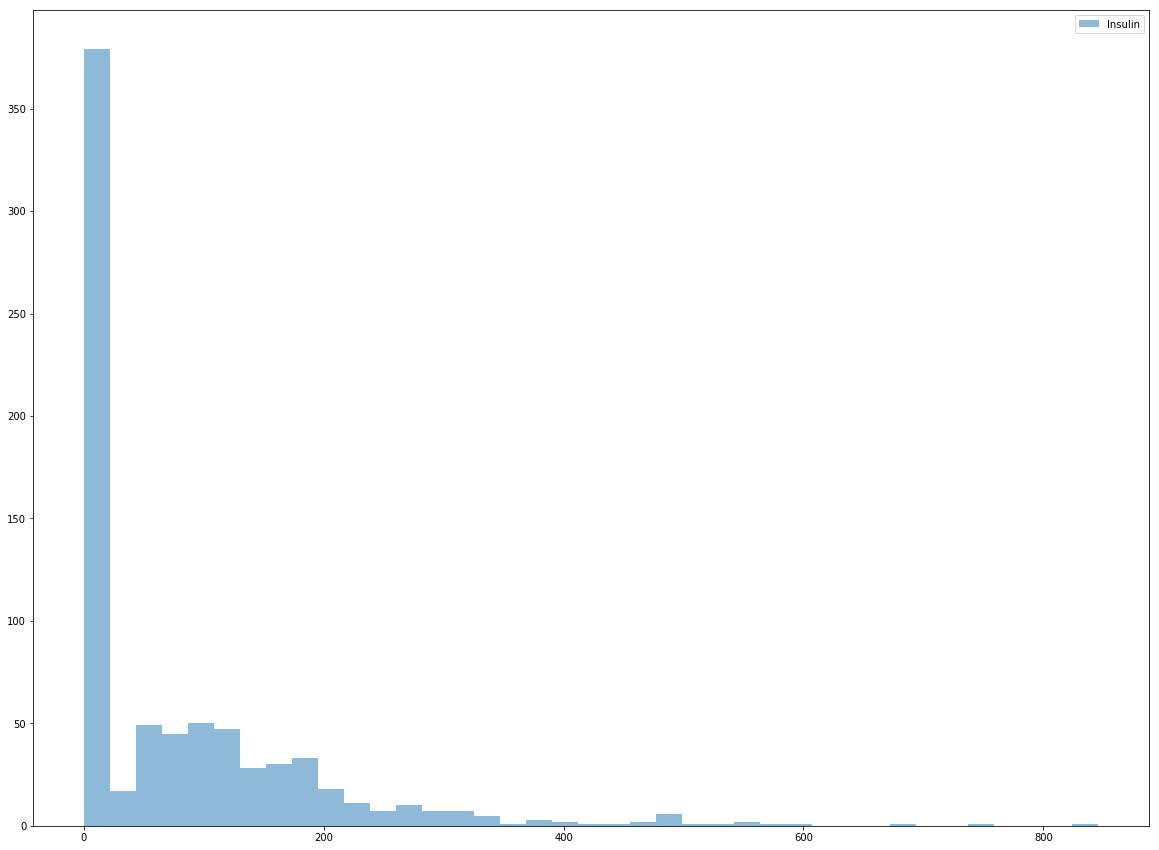

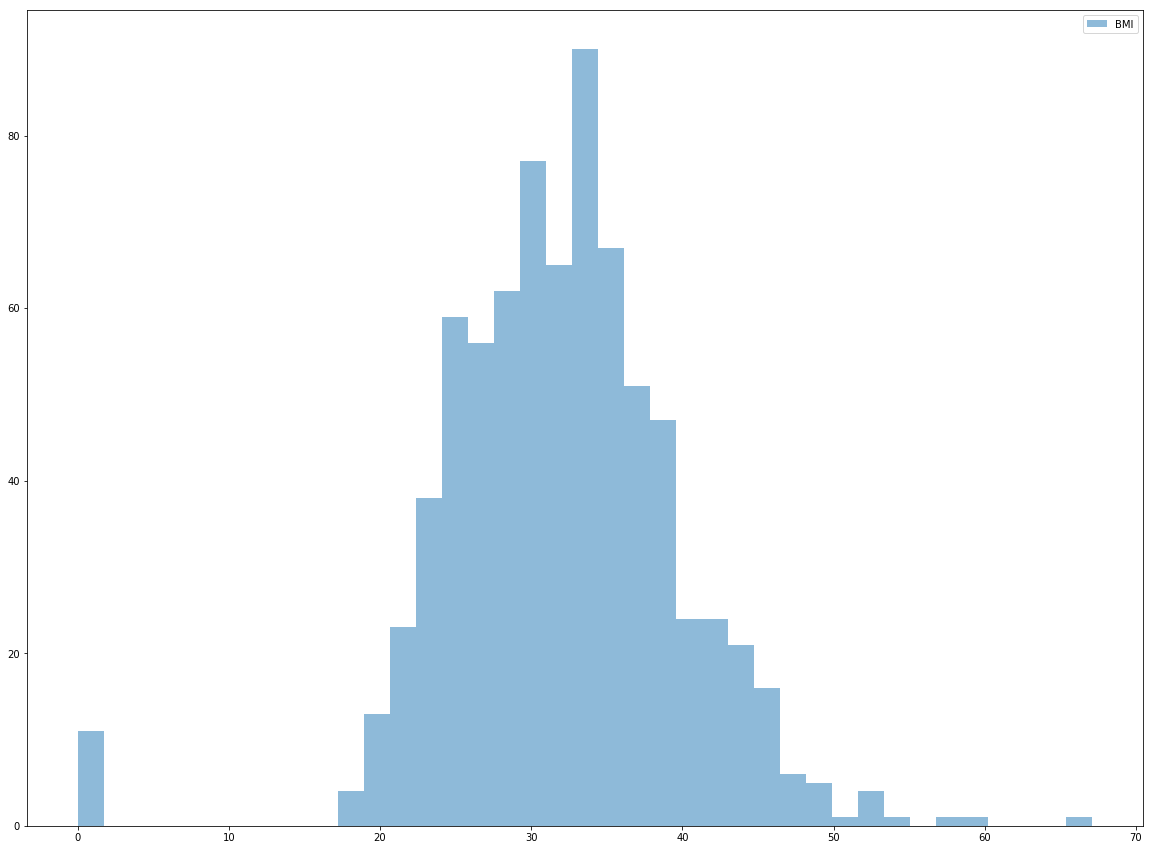

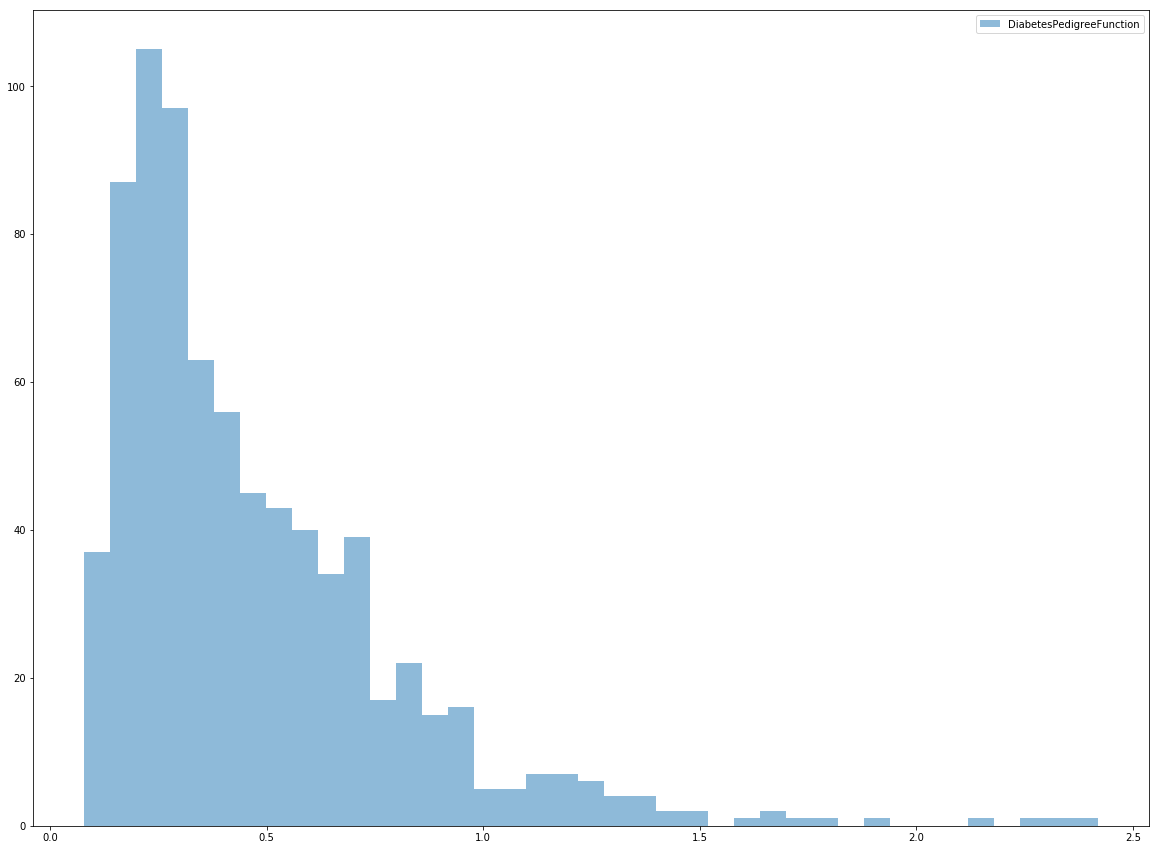

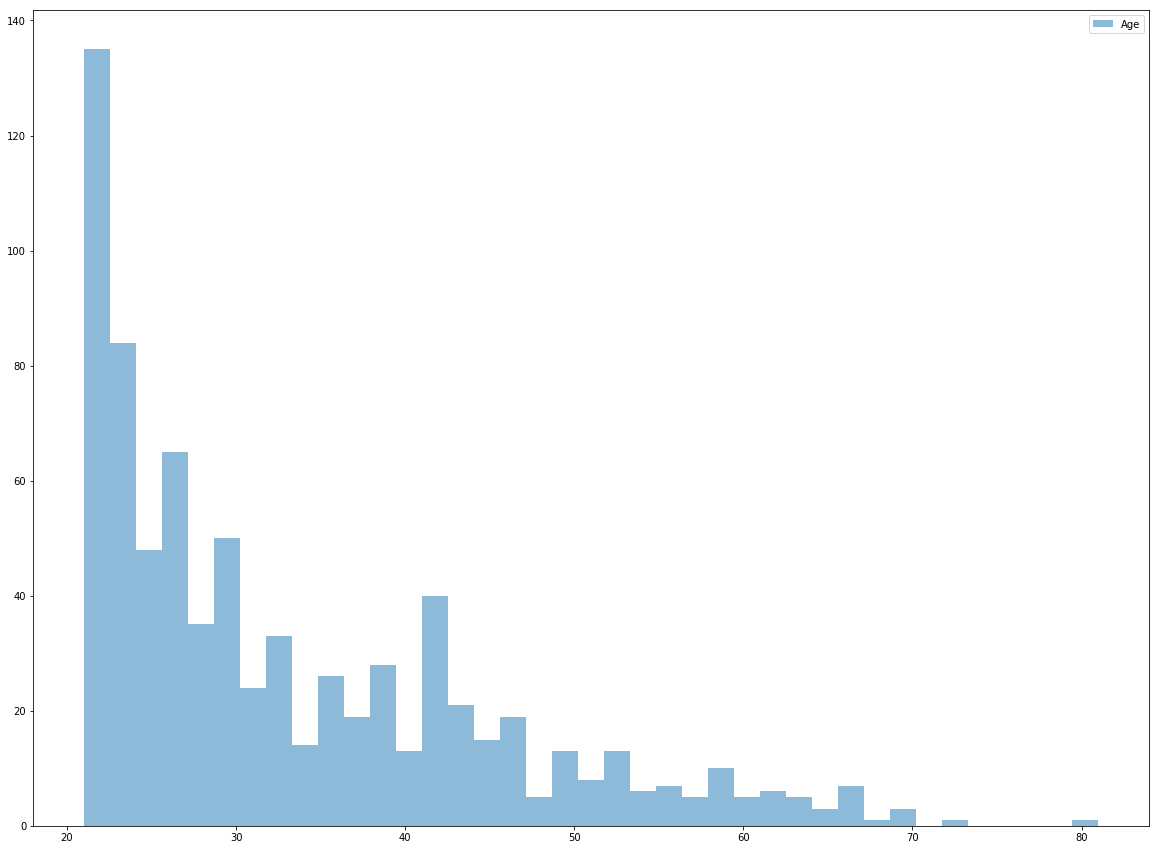

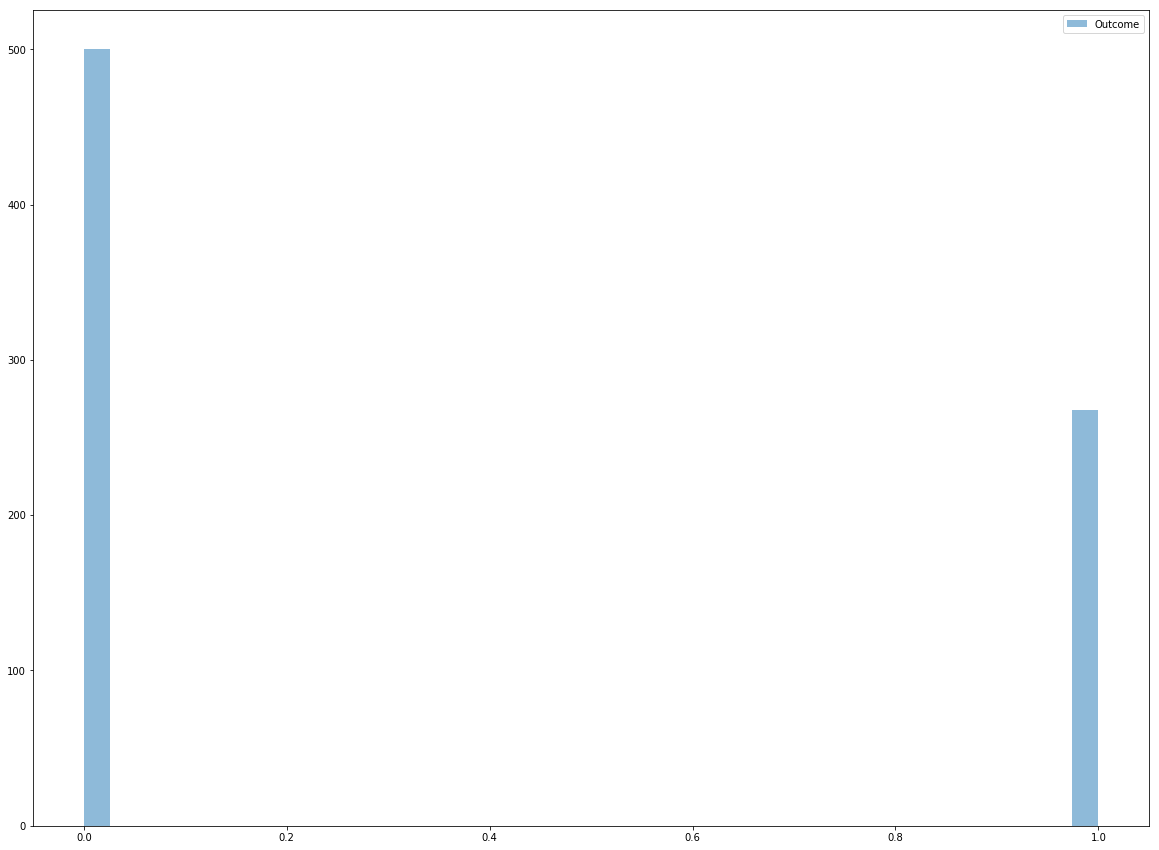

In [195]:
#Now call this function on the original dataframe above
show_quant_feature_hist_plot(orig_diabetes_df)

The below plots (after z-score transformation, is an attempt to see if there are outliers present

many of these features actually show outliers (z-score > +3.0), but as the target model (SVM in this case) is quite immune to outliers, we will not attempt to remove them.

Text(0.5, 1.0, 'Before Scaling')

Text(0.5, 1.0, 'After Standard Scaler')

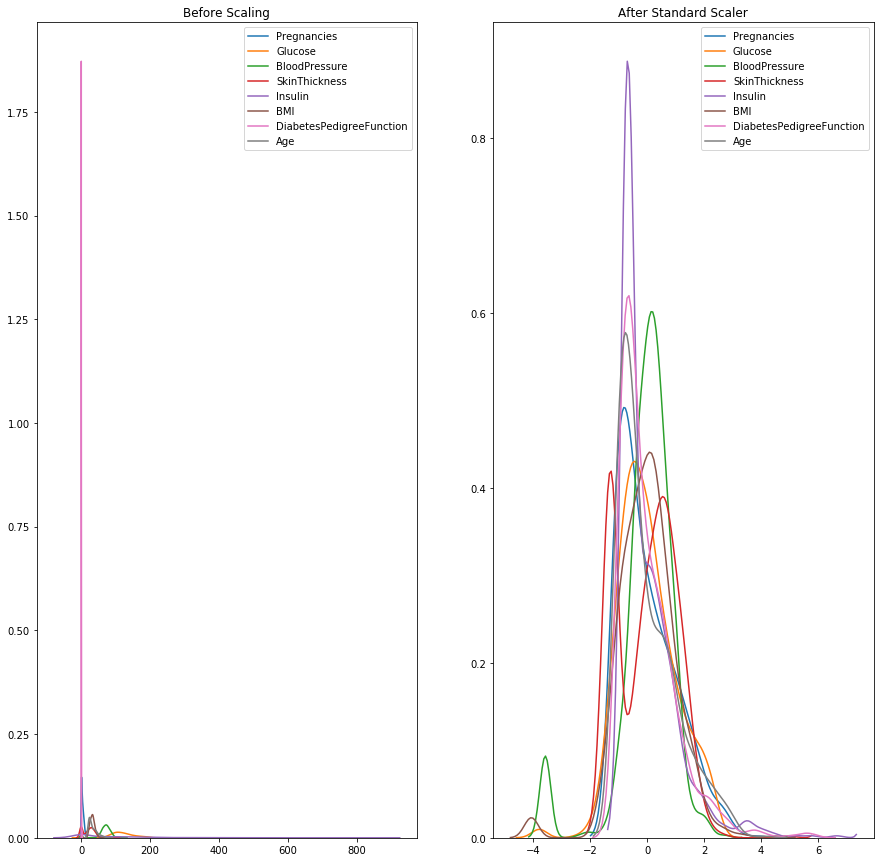

In [196]:
# The result on the z-score (standardScalar transform) can also be looked at
# which can be used to ascertain outliers (thumb rule: z score beyond +/-3.0 values)...
# but we don't worry about the "outlier-tails" below for many features (with SVM being at the back our minds)
from sklearn import preprocessing
descr_trans_df = orig_diabetes_df.describe()
scaler = preprocessing.StandardScaler()
scaled_X = scaler.fit_transform(orig_diabetes_df[list(descr_trans_df.T.index)])
scaled_X = pd.DataFrame(scaled_X, columns=list(descr_trans_df.T.index))
fig, (ax1, ax2) = pyplot.subplots(ncols=2, figsize=(15, 15))
ax1.set_title('Before Scaling')
for i in list(orig_diabetes_df.T.index)[0:len(col_name_full)-1]:
    sns.kdeplot(orig_diabetes_df[i], ax=ax1)
ax2.set_title('After Standard Scaler')
for i in list(orig_diabetes_df.T.index)[0:len(col_name_full)-1]:
    sns.kdeplot(scaled_X[i], ax=ax2)
pyplot.show()

### Do correlation analysis and bivariate viualization with Insights(1 Marks)

(<Figure size 1440x1080 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x1f497549c88>)

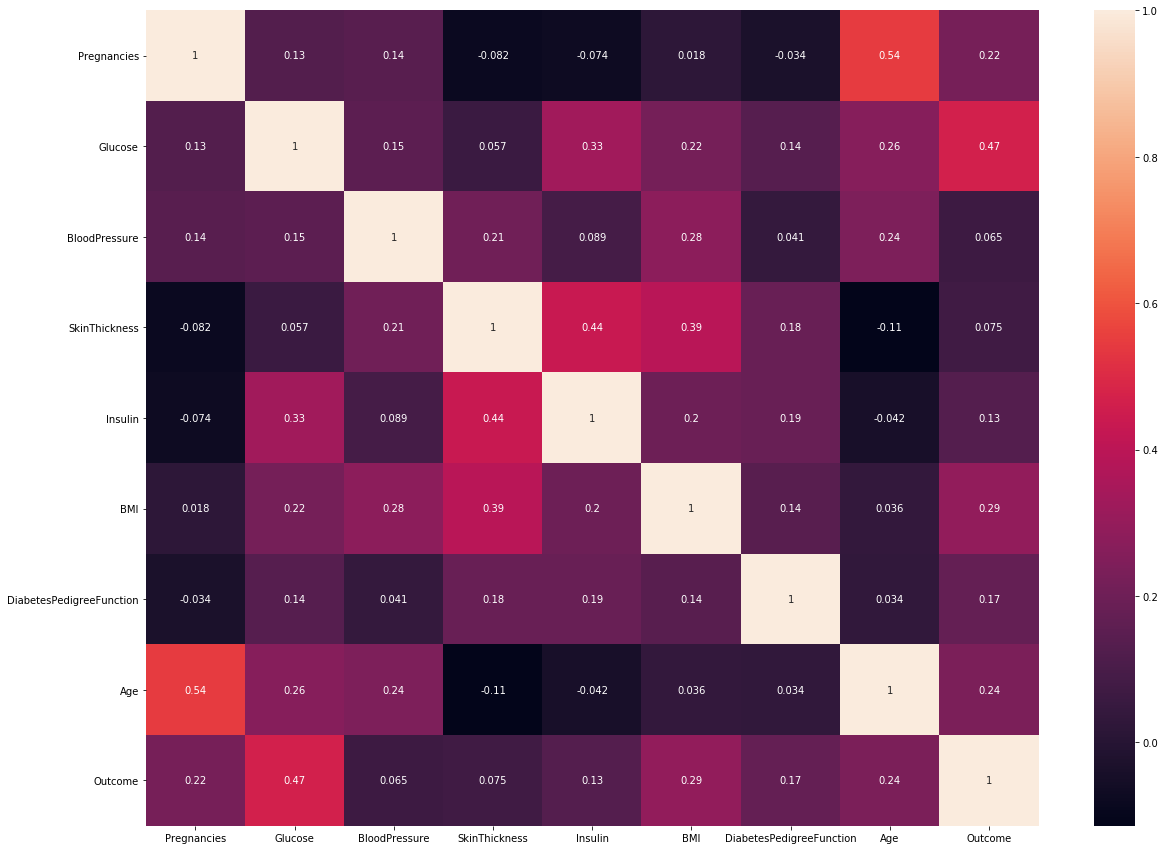

In [197]:
#Now it is required to get a visual sense of the correlation matrix to find the 
#highly correlated "almost white patches" of features 
pyplot.subplots(figsize=(20,15))
sns.heatmap(orig_diabetes_df.corr(), annot=True)

Outcome variable almost doesn't have any correlation with BloodPressre and SkinThickness(actually with many othres too, it is weakly correlated)

#### Do train and test split with stratify sampling on Outcome variable to maintain the distribution of dependent variable(1 Marks)

In [198]:
# splitting data into training and test set for independent attributes
from sklearn.model_selection import train_test_split

X =  orig_diabetes_df.drop("Outcome", axis=1)
y =  orig_diabetes_df.pop("Outcome")

train_set, test_set, train_labels, test_labels = train_test_split(X, y, test_size=0.30, random_state=7, stratify=y)

### Train Support Vector Machine Model(1 Marks)

In [199]:
# use from sklearn.svm import SVC
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

In [200]:
# your insights
svc_mdl = SVC(kernel='linear', C=1)

### Scale the data points using MinMaxScaler ( 1 Marks)

In [201]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_set)
test_set_scaled = scaler.fit_transform(test_set)

### Fit SVM Model on Scale data and give your observation( 1 Marks)

In [202]:
svc_mdl.fit(train_scaled, train_labels)

SVC(C=1, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='linear', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [203]:
preds = svc_mdl.predict(test_set_scaled)
cm = confusion_matrix(test_labels, preds)
print (cm)
print(f1_score(test_labels, preds))
print(accuracy_score(test_labels, preds))

[[130  20]
 [ 38  43]]
0.5972222222222223
0.7489177489177489


#we can try increasing either C or gamma to fit a more complex model.

### Try improving the model accuracy using C=1000 (1 Marks)

In [204]:
svc_mdl_C_1000 = SVC(kernel='linear', C=1000)

In [205]:
svc_mdl_C_1000.fit(train_scaled, train_labels)

SVC(C=1000, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='linear', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [206]:
preds = svc_mdl_C_1000.predict(test_set_scaled)
cm = confusion_matrix(test_labels, preds)
print (cm)
print(f1_score(test_labels, preds))
print(accuracy_score(test_labels, preds))

[[130  20]
 [ 37  44]]
0.6068965517241379
0.7532467532467533


### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [210]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [211]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [212]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [213]:
gs.fit(train_scaled, train_labels) 

GridSearchCV(cv=10, error_score='raise-deprecating',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False),
       fit_params=None, iid='warn', n_jobs=12,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='accuracy', verbose=0)

In [214]:
gs.best_estimator_

SVC(C=1.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [215]:
gs.best_score_ 

0.770949720670391